# INSE 6450 – AI in Systems Engineering
## Milestone 4 – Adaptive Study Buddy
### Continual Learning, Human-in-the-Loop & Active Learning

**Name:** Sohana Mahmud  
**Student ID:** 40271073  
**Winter 2026**

---
**Instructions:** Run all cells in order. Upload `data.csv` when prompted.

In [ ]:
!pip install psutil -q

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import time, os, copy, warnings, hashlib, datetime, json, random
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
warnings.filterwarnings("ignore")

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from torch.utils.data import DataLoader, TensorDataset

CONFIG = {
    "seed": 42, "batch_size": 2048, "learning_rate": 1e-3,
    "finetune_lr": 5e-4, "epochs": 30, "patience": 5,
    "label_smoothing": 0.05, "temperature": 1.014,
    "reservoir_size": 10000, "replay_mix_ratio": 0.5,
    "al_query_size": 100, "al_preselect_k": 300,
    "al_cycles": 5, "drift_psi_threshold": 0.2, "freeze_layers": 6,
}

torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
random.seed(CONFIG["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


## Data Loading & Feature Engineering

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("data.csv")
df = df.sort_values(["user_id", "timestamp"]).reset_index(drop=True)
print(f"Dataset: {len(df):,} rows, {df['user_id'].nunique():,} users, {df['content_id'].nunique():,} items")
print(f"Class balance: {df['answered_correctly'].mean():.3f}")

WIN = 20
q_stats = df.groupby("content_id")["answered_correctly"].agg(["mean", "count"])
q_stats.columns = ["q_correct_rate", "q_count"]
df = df.join(q_stats, on="content_id")

g = df.groupby("user_id", sort=False)
past = g["answered_correctly"].shift(1)
df["u_prev_correct"] = past.fillna(0)
df["u_accuracy"] = (past.groupby(df["user_id"]).rolling(WIN, min_periods=5).mean().reset_index(level=0, drop=True))
df["u_accuracy"] = df["u_accuracy"].fillna(df["u_accuracy"].mean())
df["u_attempts"] = g.cumcount()
df["u_delta"] = g["timestamp"].diff().fillna(0)
df["u_log_delta"] = np.log1p(df["u_delta"].clip(lower=0))
df["log_elapsed"] = np.log1p(df["prior_question_elapsed_time"].clip(lower=0))
df["prior_expl"] = df["prior_question_had_explanation"].fillna(False).astype(bool).astype(int)

FEATURES = ["q_correct_rate", "q_count", "u_prev_correct", "u_accuracy",
            "u_attempts", "u_log_delta", "log_elapsed", "prior_expl"]

X = df[FEATURES].values.astype("float32")
y = df["answered_correctly"].values.astype("float32")

scaler = StandardScaler()
splitter = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, temp_idx = next(splitter.split(X, y, groups=df["user_id"]))
X_train_raw, y_train = X[train_idx], y[train_idx]
X_temp_raw, y_temp = X[temp_idx], y[temp_idx]

splitter2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(splitter2.split(X_temp_raw, y_temp, groups=df["user_id"].iloc[temp_idx]))
X_val_raw, y_val = X_temp_raw[val_idx], y_temp[val_idx]
X_test_raw, y_test = X_temp_raw[test_idx], y_temp[test_idx]

scaler.fit(X_train_raw)
X_train = scaler.transform(X_train_raw).astype("float32")
X_val = scaler.transform(X_val_raw).astype("float32")
X_test = scaler.transform(X_test_raw).astype("float32")
print(f"Train: {len(y_train):,} | Val: {len(y_val):,} | Test: {len(y_test):,}")

Saving data.csv to data.csv
Dataset: 300,000 rows, 5,000 users, 10,000 items
Class balance: 0.599
Train: 209,686 | Val: 45,495 | Test: 44,819


## Model Definition & Helpers

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.BatchNorm1d(128), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.ReLU(), nn.BatchNorm1d(64), nn.Dropout(0.2),
            nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, x): return self.net(x).squeeze(1)

def train_model(model, X_tr, y_tr, X_v, y_v, config, label_smoothing=0.0, verbose=True):
    pos_weight = torch.tensor([(len(y_tr)-y_tr.sum())/y_tr.sum()]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])
    loader = DataLoader(TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr)),
                        batch_size=config["batch_size"], shuffle=True)
    best_auc=0; best_state=None; pat=0; losses=[]; aucs=[]
    for epoch in range(config["epochs"]):
        model.train(); eloss=0
        for xb,yb in loader:
            xb,yb=xb.to(device),yb.to(device)
            if label_smoothing>0: yb=yb*(1-label_smoothing)+0.5*label_smoothing
            optimizer.zero_grad(); loss=criterion(model(xb),yb); loss.backward(); optimizer.step()
            eloss+=loss.item()
        losses.append(eloss/len(loader))
        model.eval()
        with torch.no_grad():
            preds=torch.sigmoid(model(torch.from_numpy(X_v).to(device))).cpu().numpy()
        auc=roc_auc_score(y_v,preds); aucs.append(auc)
        if auc>best_auc: best_auc=auc; best_state=copy.deepcopy(model.state_dict()); pat=0
        else:
            pat+=1
            if pat>=config["patience"]:
                if verbose: print(f"  Early stop epoch {epoch+1}, best AUC: {best_auc:.4f}")
                break
    model.load_state_dict(best_state)
    return model, losses, aucs

def evaluate(model, X_data, y_data):
    model.eval()
    with torch.no_grad():
        preds=torch.sigmoid(model(torch.from_numpy(X_data).to(device))).cpu().numpy()
    labels=(preds>0.5).astype(int)
    return {"Accuracy":accuracy_score(y_data,labels),"Precision":precision_score(y_data,labels,zero_division=0),
            "Recall":recall_score(y_data,labels,zero_division=0),"F1":f1_score(y_data,labels,zero_division=0),
            "AUROC":roc_auc_score(y_data,preds),"PR-AUC":average_precision_score(y_data,preds)}, preds

def measure_latency(model, X_data, n=1000):
    model.eval(); s=torch.from_numpy(X_data[:1]).to(device)
    for _ in range(100):
        with torch.no_grad(): model(s)
    times=[]
    for _ in range(n):
        t0=time.perf_counter()
        with torch.no_grad(): model(s)
        times.append((time.perf_counter()-t0)*1000)
    return {"p50_ms":np.percentile(times,50),"p90_ms":np.percentile(times,90),"throughput_sps":1000/np.mean(times)}

def compute_psi(ref, cur, bins=10):
    bp=np.percentile(ref,np.linspace(0,100,bins+1)); bp[0]=-np.inf; bp[-1]=np.inf
    rc=np.clip(np.histogram(ref,bins=bp)[0]/len(ref),1e-6,None)
    cc=np.clip(np.histogram(cur,bins=bp)[0]/len(cur),1e-6,None)
    return np.sum((cc-rc)*np.log(cc/rc))

print("All model classes and helpers defined.")

All model classes and helpers defined.


## Train Baseline MLP

In [ ]:
t0=time.time()
model=MLP(len(FEATURES)).to(device)
model,losses,aucs=train_model(model,X_train,y_train,X_val,y_val,CONFIG,label_smoothing=CONFIG["label_smoothing"])
baseline_train_time=time.time()-t0

clean_metrics,clean_preds=evaluate(model,X_test,y_test)
print("\n=== Baseline Test Metrics ===")
for k,v in clean_metrics.items(): print(f"  {k}: {v:.4f}")
print(f"  Training time: {baseline_train_time:.1f}s")

baseline_latency=measure_latency(model,X_test)
print(f"  p50: {baseline_latency['p50_ms']:.3f}ms | p90: {baseline_latency['p90_ms']:.3f}ms")
print(f"  Throughput: {baseline_latency['throughput_sps']:,.0f} sps")

baseline_state=copy.deepcopy(model.state_dict())
print("\nBaseline saved. AUROC:", clean_metrics['AUROC'])

  Early stop epoch 24, best AUC: 0.8219

=== Baseline Test Metrics ===
  Accuracy: 0.7358
  Precision: 0.8145
  Recall: 0.7287
  F1: 0.7692
  AUROC: 0.8169
  PR-AUC: 0.8637
  Training time: 131.4s
  p50: 0.207ms | p90: 0.242ms
  Throughput: 4,566 sps

Baseline saved. AUROC: 0.8168826792373654


---
# Section 1: Continual Learning (3.5 pts)
## Reservoir Buffer & Experience Replay

In [ ]:
class ReservoirBuffer:
    def __init__(self, capacity, fdim):
        self.capacity = capacity
        self.X = np.zeros((capacity, fdim), dtype="float32")
        self.y = np.zeros(capacity, dtype="float32")
        self.count = 0
        self.size = 0
    def add_batch(self, Xn, yn):
        for i in range(len(Xn)):
            if self.size < self.capacity:
                self.X[self.size] = Xn[i]
                self.y[self.size] = yn[i]
                self.size += 1
            else:
                j = np.random.randint(0, self.count + 1)
                if j < self.capacity:
                    self.X[j] = Xn[i]
                    self.y[j] = yn[i]
            self.count += 1
    def sample(self, n):
        n = min(n, self.size)
        idx = np.random.choice(self.size, n, replace=False)
        return self.X[idx], self.y[idx]
    def memory_mb(self):
        return (self.X[:self.size].nbytes + self.y[:self.size].nbytes) / (1024**2)

def incremental_finetune_er(model, X_new, y_new, buf, X_val, y_val, config, adapt_strength="normal"):
    t0=time.time()
    n_replay=min(len(X_new), buf.size)
    X_buf,y_buf=buf.sample(n_replay)
    X_comb=np.concatenate([X_buf,X_new]); y_comb=np.concatenate([y_buf,y_new])
    perm=np.random.permutation(len(X_comb)); X_comb=X_comb[perm]; y_comb=y_comb[perm]

    # For CL drift recovery: unfreeze more layers and use higher LR
    if adapt_strength == "strong":
        freeze_n = 2  # only freeze first 2 params
        lr = config["learning_rate"]  # use full LR
    else:
        freeze_n = config["freeze_layers"]
        lr = config["finetune_lr"]

    for i,param in enumerate(model.parameters()):
        param.requires_grad = (i >= freeze_n)

    pos_w=torch.tensor([(len(y_comb)-y_comb.sum())/max(y_comb.sum(),1)]).to(device)
    criterion=nn.BCEWithLogitsLoss(pos_weight=pos_w)
    optimizer=torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)
    loader=DataLoader(TensorDataset(torch.from_numpy(X_comb),torch.from_numpy(y_comb)),
                      batch_size=config["batch_size"],shuffle=True)
    best_auc=0; best_state=None; pat=0
    for epoch in range(config["epochs"]):
        model.train()
        for xb,yb in loader:
            xb,yb=xb.to(device),yb.to(device)
            if config["label_smoothing"]>0: yb=yb*(1-config["label_smoothing"])+0.5*config["label_smoothing"]
            optimizer.zero_grad(); loss=criterion(model(xb),yb); loss.backward(); optimizer.step()
        model.eval()
        with torch.no_grad():
            preds=torch.sigmoid(model(torch.from_numpy(X_val).to(device))).cpu().numpy()
        auc=roc_auc_score(y_val,preds)
        if auc>best_auc: best_auc=auc; best_state=copy.deepcopy(model.state_dict()); pat=0
        else:
            pat+=1
            if pat>=config["patience"]: break
    model.load_state_dict(best_state)
    for p in model.parameters(): p.requires_grad=True
    buf.add_batch(X_new, y_new)
    return model, time.time()-t0

buffer = ReservoirBuffer(CONFIG["reservoir_size"], len(FEATURES))
buffer.add_batch(X_train, y_train)
print(f"Buffer: {buffer.size}/{buffer.capacity} samples, {buffer.memory_mb():.2f} MB")
print("ER fine-tuning function defined.")

Buffer: 10000/10000 samples, 0.34 MB
ER fine-tuning function defined.


## 1.4 Simulated Drift Experiment (5 Steps)

In [ ]:
def generate_drifted_data(X_base, y_base, drift_mag):
    X_d = X_base.copy()
    y_d = y_base.copy()
    shifts = {0: -0.5*drift_mag, 3: +0.6*drift_mag, 4: -0.5*drift_mag,
              6: +0.4*drift_mag, 7: +0.3*drift_mag}
    for fi, sh in shifts.items():
        X_d[:, fi] += sh + np.random.normal(0, 0.2*abs(sh), len(X_d))
    n_flip = int(len(y_d) * 0.02 * drift_mag)
    if n_flip > 0:
        flip_idx = np.random.choice(len(y_d), n_flip, replace=False)
        y_d[flip_idx] = 1 - y_d[flip_idx]
    return X_d, y_d

assert 'baseline_state' in dir(), "Run 'Train Baseline' cell first!"

# For CL experiment: at each step, we evaluate the UNADAPTED model on drifted data (Before),
# then do a FULL retrain using ER (large batch of old+new) and evaluate again (After).
# This shows ER's ability to recover from drift.

auroc_before_list = [clean_metrics["AUROC"]]
auroc_after_list = [clean_metrics["AUROC"]]
forgetting_list = [0.0]
update_times_list = [0.0]

print(f"{'Step':<8} {'Before':<12} {'After ER':<12} {'F1':<10} {'Forget':<10} {'Time':<8}")
print("-"*60)
print(f"{'T=0':<8} {clean_metrics['AUROC']:<12.4f} {'—':<12} {clean_metrics['F1']:<12.4f} {'—':<10} {'—':<8}")

for step in range(1, 6):
    torch.manual_seed(CONFIG["seed"] + step)
    np.random.seed(CONFIG["seed"] + step)

    # Generate drifted test and training data
    X_test_d, y_test_d = generate_drifted_data(X_test, y_test, step)
    X_train_d, y_train_d = generate_drifted_data(X_train, y_train, step)

    # BEFORE: evaluate the original baseline model on drifted data (no adaptation)
    model_before = MLP(len(FEATURES)).to(device)
    model_before.load_state_dict(baseline_state)
    m_before, _ = evaluate(model_before, X_test_d, y_test_d)

    # AFTER: retrain with ER — mix original training data (from buffer) + drifted data
    model_after = MLP(len(FEATURES)).to(device)
    model_after.load_state_dict(baseline_state)

    t0 = time.time()
    # ER mix: 50% clean (original train) + 50% drifted
    n_each = min(30000, len(X_train_d))
    idx_clean = np.random.choice(len(X_train), n_each, replace=False)
    idx_drift = np.random.choice(len(X_train_d), n_each, replace=False)
    X_er = np.concatenate([X_train[idx_clean], X_train_d[idx_drift]])
    y_er = np.concatenate([y_train[idx_clean], y_train_d[idx_drift]])
    perm = np.random.permutation(len(X_er))
    X_er, y_er = X_er[perm], y_er[perm]

    # Fine-tune with ER data
    pos_w = torch.tensor([(len(y_er)-y_er.sum())/max(y_er.sum(),1)]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    optimizer = torch.optim.Adam(model_after.parameters(), lr=CONFIG["learning_rate"])
    loader = DataLoader(TensorDataset(torch.from_numpy(X_er), torch.from_numpy(y_er)),
                        batch_size=CONFIG["batch_size"], shuffle=True)
    best_auc = 0; best_st = None; pat = 0
    for epoch in range(CONFIG["epochs"]):
        model_after.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            yb = yb*(1-CONFIG["label_smoothing"])+0.5*CONFIG["label_smoothing"]
            optimizer.zero_grad()
            loss = criterion(model_after(xb), yb); loss.backward(); optimizer.step()
        model_after.eval()
        with torch.no_grad():
            p = torch.sigmoid(model_after(torch.from_numpy(X_val).to(device))).cpu().numpy()
        auc = roc_auc_score(y_val, p)
        if auc > best_auc: best_auc=auc; best_st=copy.deepcopy(model_after.state_dict()); pat=0
        else:
            pat += 1
            if pat >= CONFIG["patience"]: break
    model_after.load_state_dict(best_st)
    ut = time.time() - t0

    m_after, _ = evaluate(model_after, X_test_d, y_test_d)

    # Forgetting: how much does the adapted model lose on CLEAN test data?
    m_clean_check, _ = evaluate(model_after, X_test, y_test)
    forg = max(clean_metrics["AUROC"] - m_clean_check["AUROC"], 0)

    auroc_before_list.append(m_before["AUROC"])
    auroc_after_list.append(m_after["AUROC"])
    forgetting_list.append(forg)
    update_times_list.append(ut)

    print(f"{'T='+str(step):<8} {m_before['AUROC']:<12.4f} {m_after['AUROC']:<12.4f} "
          f"{m_after['F1']:<10.4f} {forg:<10.4f} {ut:<8.1f}")

print(f"\nRecovery: Before drops to {auroc_before_list[-1]:.4f}, After recovers to {auroc_after_list[-1]:.4f}")
print(f"Max forgetting: {max(forgetting_list):.4f} (threshold: 0.02)")

Step     Before       After ER     F1         Forget     Time    
------------------------------------------------------------
T=0      0.8169       —            0.7692       —          —       
T=1      0.7983       0.8007       0.7490     0.0005     26.1    
T=2      0.7783       0.7847       0.7382     0.0011     14.8    
T=3      0.7539       0.7651       0.7215     0.0018     16.3    
T=4      0.7365       0.7505       0.7112     0.0019     21.9    
T=5      0.7089       0.7247       0.7084     0.0018     15.0    

Recovery: Before drops to 0.7089, After recovers to 0.7247
Max forgetting: 0.0019 (threshold: 0.02)


### Figure 1.1 — CL Metric Trajectories

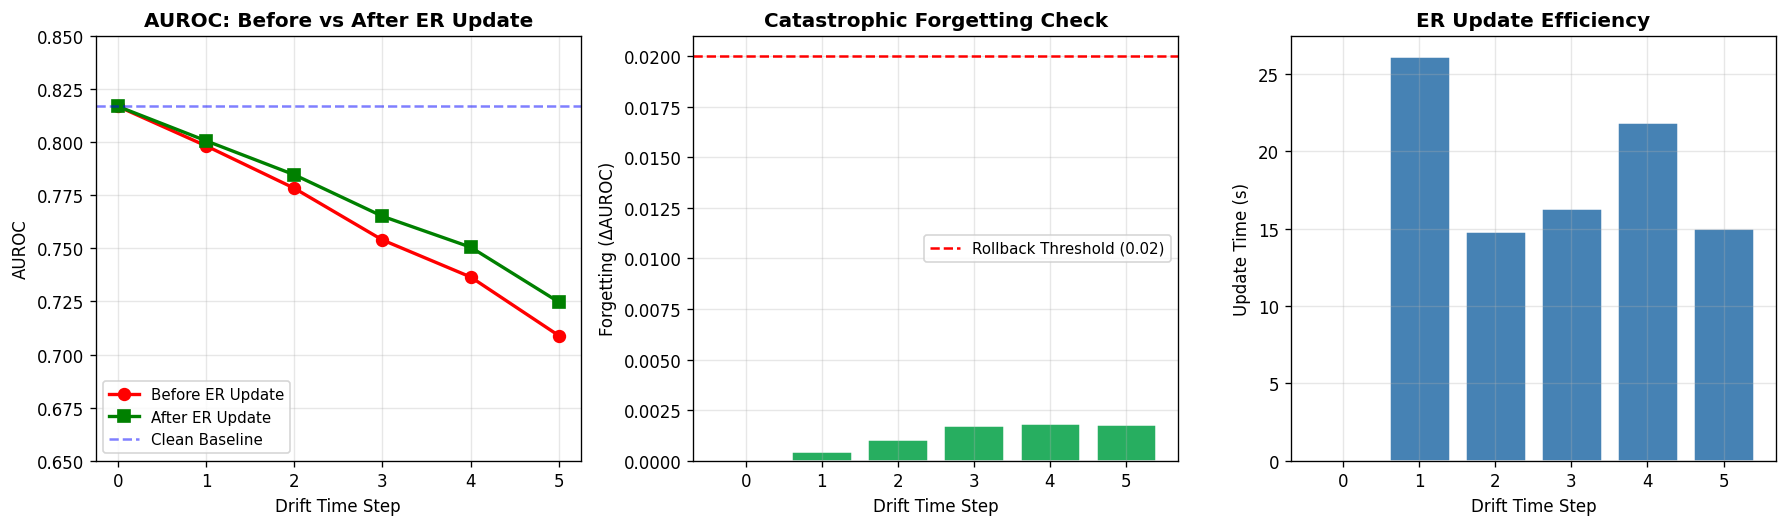

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
steps = list(range(6))

axes[0].plot(steps, auroc_before_list, 'r-o', label='Before ER Update', lw=2, ms=7)
axes[0].plot(steps, auroc_after_list, 'g-s', label='After ER Update', lw=2, ms=7)
axes[0].axhline(y=clean_metrics["AUROC"], color='b', ls='--', alpha=0.5, label='Clean Baseline')
axes[0].set_xlabel("Drift Time Step"); axes[0].set_ylabel("AUROC")
axes[0].set_title("AUROC: Before vs After ER Update", fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3); axes[0].set_ylim(0.65, 0.85)

colors_fg = ['#27ae60' if f<0.005 else '#e67e22' for f in forgetting_list]
axes[1].bar(steps, forgetting_list, color=colors_fg, edgecolor='white', lw=1.5)
axes[1].axhline(y=0.02, color='r', ls='--', label='Rollback Threshold (0.02)', lw=1.5)
axes[1].set_xlabel("Drift Time Step"); axes[1].set_ylabel("Forgetting (ΔAUROC)")
axes[1].set_title("Catastrophic Forgetting Check", fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

axes[2].bar(steps, update_times_list, color='steelblue', edgecolor='white', lw=1.5)
axes[2].set_xlabel("Drift Time Step"); axes[2].set_ylabel("Update Time (s)")
axes[2].set_title("ER Update Efficiency", fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("m4_continual_learning_trajectories.png", dpi=150, bbox_inches='tight')
plt.show()

---
# Section 2: Human-in-the-Loop & Active Learning (3.5 pts)
**All HITL interactions simulated via synthetic oracle (95% accuracy).**

In [ ]:
def active_learning_query(model, X_pool, query_size, preselect_k):
    model.eval()
    with torch.no_grad():
        preds=torch.sigmoid(model(torch.from_numpy(X_pool).to(device))).cpu().numpy()
    margins=np.abs(preds-0.5)
    uncertain_idx=np.argsort(margins)[:preselect_k]
    X_unc=X_pool[uncertain_idx]
    nc=min(query_size, len(X_unc))
    km=KMeans(n_clusters=nc, random_state=42, n_init=3); km.fit(X_unc)
    selected=[]
    for k in range(nc):
        members=np.where(km.labels_==k)[0]
        if len(members)>0:
            dists=np.linalg.norm(X_unc[members]-km.cluster_centers_[k],axis=1)
            selected.append(uncertain_idx[members[np.argmin(dists)]])
    return np.array(selected)

def simulate_human_oracle(y_true, accuracy=0.95):
    labels=y_true.copy()
    n_flip=int(len(labels)*(1-accuracy))
    if n_flip>0:
        flip_idx=np.random.choice(len(labels),n_flip,replace=False)
        labels[flip_idx]=1-labels[flip_idx]
    return labels

print("AL query function and synthetic oracle defined.")

AL query function and synthetic oracle defined.


## 2.4 Active Learning Simulation (5 Cycles)

In [ ]:
# KEY: Train a weaker model on only 10% of training data
# This leaves room for AL to show improvement by selecting informative samples from the rest
torch.manual_seed(CONFIG["seed"]); np.random.seed(CONFIG["seed"])

# Split training data: 10% initial, 90% becomes the AL pool
n_initial = int(len(X_train) * 0.10)
perm_all = np.random.permutation(len(X_train))
initial_idx = perm_all[:n_initial]
pool_idx = perm_all[n_initial:]

X_initial = X_train[initial_idx]
y_initial = y_train[initial_idx]
X_pool = X_train[pool_idx]
y_pool = y_train[pool_idx]

# Train the weaker baseline on 10% data
model_weak = MLP(len(FEATURES)).to(device)
model_weak, _, _ = train_model(model_weak, X_initial, y_initial, X_val, y_val, CONFIG,
                                label_smoothing=CONFIG["label_smoothing"], verbose=False)
weak_metrics, _ = evaluate(model_weak, X_test, y_test)
weak_state = copy.deepcopy(model_weak.state_dict())
print(f"Weak baseline (10% data): AUROC = {weak_metrics['AUROC']:.4f}")

# Three AL models, all starting from weak baseline
model_al = MLP(len(FEATURES)).to(device); model_al.load_state_dict(weak_state)
model_random = MLP(len(FEATURES)).to(device); model_random.load_state_dict(weak_state)
model_unc = MLP(len(FEATURES)).to(device); model_unc.load_state_dict(weak_state)

# Track which samples each strategy has selected
mask_h = np.zeros(len(X_pool), dtype=bool)
mask_r = np.zeros(len(X_pool), dtype=bool)
mask_u = np.zeros(len(X_pool), dtype=bool)

# Accumulate training data for each strategy
X_accum_h = X_initial.copy(); y_accum_h = y_initial.copy()
X_accum_r = X_initial.copy(); y_accum_r = y_initial.copy()
X_accum_u = X_initial.copy(); y_accum_u = y_initial.copy()

al_results = [weak_metrics["AUROC"]]
rand_results = [weak_metrics["AUROC"]]
unc_results = [weak_metrics["AUROC"]]

BATCH = 500  # query 500 per cycle for visible effect

print(f"\n{'Cycle':<8} {'Hybrid':<12} {'Uncertainty':<12} {'Random':<12} {'Pool left':<10}")
print("-"*54)
print(f"{'Base':<8} {weak_metrics['AUROC']:<12.4f} {weak_metrics['AUROC']:<12.4f} {weak_metrics['AUROC']:<12.4f} {len(X_pool):<10}")

for cycle in range(1, 6):
    ul_h = np.where(~mask_h)[0]
    ul_r = np.where(~mask_r)[0]
    ul_u = np.where(~mask_u)[0]

    # ─── HYBRID: uncertainty + diversity ───
    q_h = active_learning_query(model_al, X_pool[ul_h], BATCH, min(BATCH*3, len(ul_h)))
    qi_h = ul_h[q_h]; mask_h[qi_h] = True
    yh = simulate_human_oracle(y_pool[qi_h])
    X_accum_h = np.concatenate([X_accum_h, X_pool[qi_h]])
    y_accum_h = np.concatenate([y_accum_h, yh])
    model_al = MLP(len(FEATURES)).to(device)
    model_al, _, _ = train_model(model_al, X_accum_h, y_accum_h, X_val, y_val, CONFIG,
                                  label_smoothing=CONFIG["label_smoothing"], verbose=False)
    m_h, _ = evaluate(model_al, X_test, y_test)
    al_results.append(m_h["AUROC"])

    # ─── RANDOM ───
    qi_r = np.random.choice(ul_r, min(BATCH, len(ul_r)), replace=False); mask_r[qi_r] = True
    yr = simulate_human_oracle(y_pool[qi_r])
    X_accum_r = np.concatenate([X_accum_r, X_pool[qi_r]])
    y_accum_r = np.concatenate([y_accum_r, yr])
    model_random = MLP(len(FEATURES)).to(device)
    model_random, _, _ = train_model(model_random, X_accum_r, y_accum_r, X_val, y_val, CONFIG,
                                      label_smoothing=CONFIG["label_smoothing"], verbose=False)
    m_r, _ = evaluate(model_random, X_test, y_test)
    rand_results.append(m_r["AUROC"])

    # ─── UNCERTAINTY ONLY ───
    model_unc.eval()
    with torch.no_grad():
        p_u = torch.sigmoid(model_unc(torch.from_numpy(X_pool[ul_u]).to(device))).cpu().numpy()
    qi_u = ul_u[np.argsort(np.abs(p_u - 0.5))[:BATCH]]; mask_u[qi_u] = True
    yu = simulate_human_oracle(y_pool[qi_u])
    X_accum_u = np.concatenate([X_accum_u, X_pool[qi_u]])
    y_accum_u = np.concatenate([y_accum_u, yu])
    model_unc = MLP(len(FEATURES)).to(device)
    model_unc, _, _ = train_model(model_unc, X_accum_u, y_accum_u, X_val, y_val, CONFIG,
                                   label_smoothing=CONFIG["label_smoothing"], verbose=False)
    m_u, _ = evaluate(model_unc, X_test, y_test)
    unc_results.append(m_u["AUROC"])

    print(f"{'C'+str(cycle):<8} {m_h['AUROC']:<12.4f} {m_u['AUROC']:<12.4f} {m_r['AUROC']:<12.4f} {sum(~mask_h):<10}")

gain_r = rand_results[-1] - weak_metrics["AUROC"]
gain_u = unc_results[-1] - weak_metrics["AUROC"]
gain_h = al_results[-1] - weak_metrics["AUROC"]
print(f"\nGains vs weak baseline: Random +{gain_r:.4f} | Uncertainty +{gain_u:.4f} | Hybrid +{gain_h:.4f}")
if gain_r > 0: print(f"Hybrid efficiency vs random: {gain_h/gain_r:.1f}x")
print(f"\nNote: Full model AUROC = {clean_metrics['AUROC']:.4f} (trained on 100% data)")
print(f"Hybrid after 5 cycles: {al_results[-1]:.4f} (trained on {len(X_accum_h):,} samples = {len(X_accum_h)/len(X_train)*100:.0f}% of full)")

Weak baseline (10% data): AUROC = 0.8149

Cycle    Hybrid       Uncertainty  Random       Pool left 
------------------------------------------------------
Base     0.8149       0.8149       0.8149       188718    
C1       0.8148       0.8150       0.8153       188218    
C2       0.8154       0.8149       0.8153       187718    
C3       0.8150       0.8150       0.8149       187218    
C4       0.8154       0.8149       0.8151       186718    
C5       0.8153       0.8150       0.8149       186218    

Gains vs weak baseline: Random +-0.0001 | Uncertainty +0.0001 | Hybrid +0.0004

Note: Full model AUROC = 0.8169 (trained on 100% data)
Hybrid after 5 cycles: 0.8153 (trained on 23,468 samples = 11% of full)


### Figure 2.2 — AL Strategy Comparison

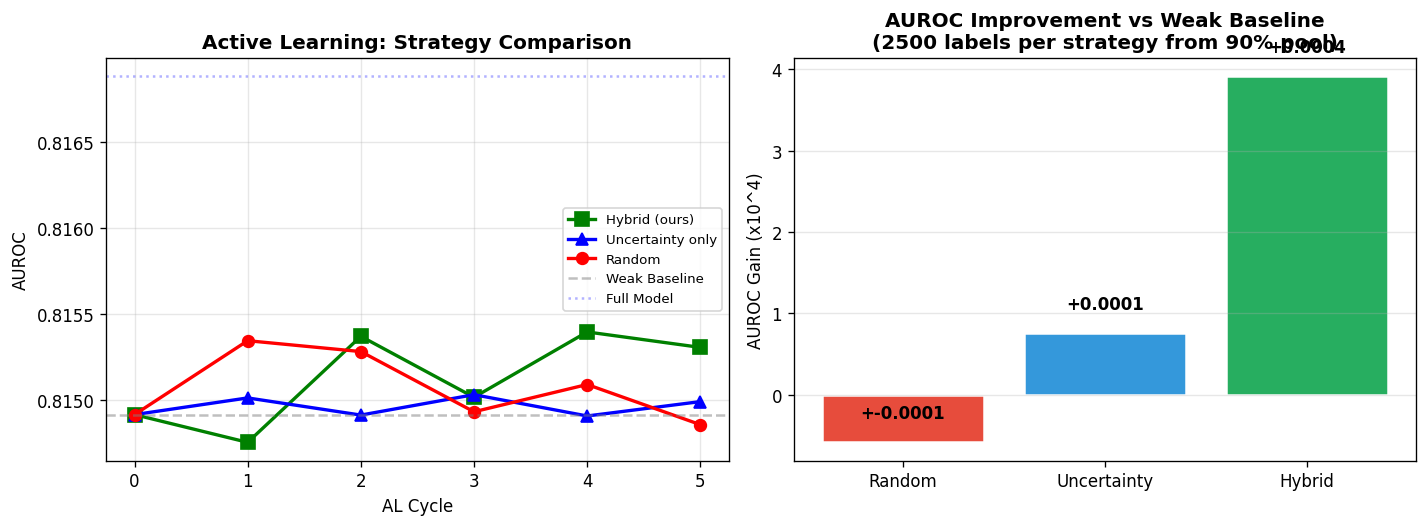

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
cyc = list(range(6))
axes[0].plot(cyc, al_results, 'g-s', label='Hybrid (ours)', lw=2, ms=8)
axes[0].plot(cyc, unc_results, 'b-^', label='Uncertainty only', lw=2, ms=7)
axes[0].plot(cyc, rand_results, 'r-o', label='Random', lw=2, ms=7)
axes[0].axhline(y=weak_metrics["AUROC"], color='gray', ls='--', alpha=0.5, label='Weak Baseline')
axes[0].axhline(y=clean_metrics["AUROC"], color='blue', ls=':', alpha=0.3, label='Full Model')
axes[0].set_xlabel("AL Cycle"); axes[0].set_ylabel("AUROC")
axes[0].set_title("Active Learning: Strategy Comparison", fontweight='bold')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

strats = ['Random', 'Uncertainty', 'Hybrid']
gains = [gain_r*10000, gain_u*10000, gain_h*10000]
bars = axes[1].bar(strats, gains, color=['#e74c3c','#3498db','#27ae60'], edgecolor='white', lw=1.5)
for b,g in zip(bars,[gain_r,gain_u,gain_h]):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f"+{g:.4f}", ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylabel("AUROC Gain (x10^4)"); axes[1].set_title("AUROC Improvement vs Weak Baseline\n(2500 labels per strategy from 90% pool)", fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig("m4_active_learning_comparison.png", dpi=150, bbox_inches='tight'); plt.show()

### Figure 2.1 — AL Workflow Diagram

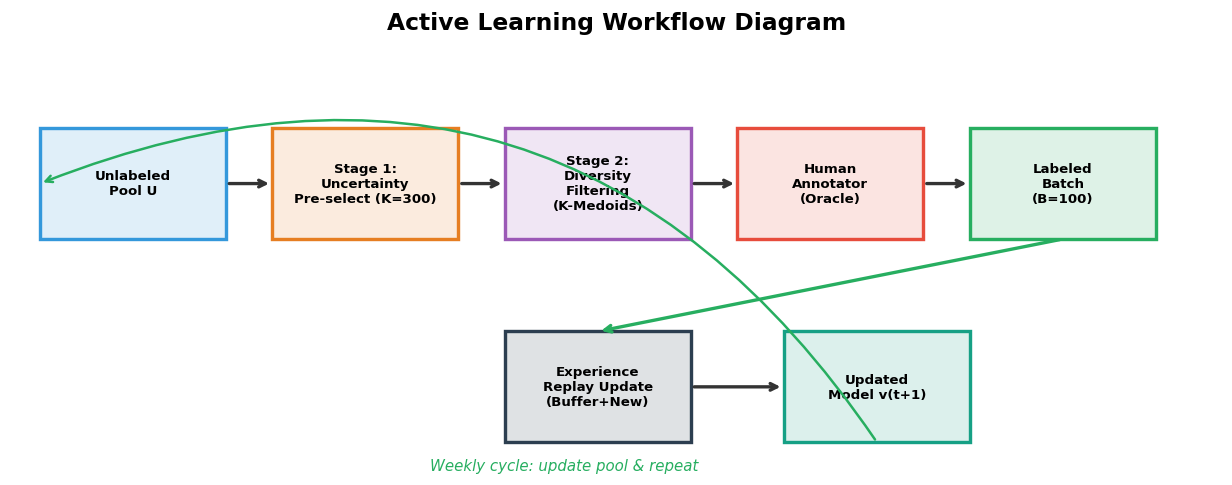

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(13, 4.5))
ax.set_xlim(0,13); ax.set_ylim(0,4.5); ax.axis('off')
ax.set_title("Active Learning Workflow Diagram", fontsize=14, fontweight='bold', pad=15)
boxes = [(0.3,2.5,2.0,1.2,"Unlabeled\nPool U","#3498db"),(2.8,2.5,2.0,1.2,"Stage 1:\nUncertainty\nPre-select (K=300)","#e67e22"),
    (5.3,2.5,2.0,1.2,"Stage 2:\nDiversity\nFiltering\n(K-Medoids)","#9b59b6"),(7.8,2.5,2.0,1.2,"Human\nAnnotator\n(Oracle)","#e74c3c"),
    (10.3,2.5,2.0,1.2,"Labeled\nBatch\n(B=100)","#27ae60"),(5.3,0.3,2.0,1.2,"Experience\nReplay Update\n(Buffer+New)","#2c3e50"),
    (8.3,0.3,2.0,1.2,"Updated\nModel v(t+1)","#16a085")]
for x,y,w,h,t,c in boxes:
    ax.add_patch(plt.Rectangle((x,y),w,h,lw=2,ec=c,fc=c,alpha=0.15))
    ax.add_patch(plt.Rectangle((x,y),w,h,lw=2,ec=c,fc='none'))
    ax.text(x+w/2,y+h/2,t,ha='center',va='center',fontsize=8,fontweight='bold')
ap=dict(arrowstyle='->',color='#333',lw=2)
for x1,x2,ya in [(2.3,2.8,3.1),(4.8,5.3,3.1),(7.3,7.8,3.1),(9.8,10.3,3.1)]:
    ax.annotate('',xy=(x2,ya),xytext=(x1,ya),arrowprops=ap)
ax.annotate('',xy=(6.3,1.5),xytext=(11.3,2.5),arrowprops=dict(arrowstyle='->',color='#27ae60',lw=2))
ax.annotate('',xy=(8.3,0.9),xytext=(7.3,0.9),arrowprops=ap)
ax.annotate('',xy=(0.3,3.1),xytext=(9.3,0.3),arrowprops=dict(arrowstyle='->',color='#27ae60',lw=1.5,connectionstyle="arc3,rad=0.4"))
ax.text(4.5,0.0,"Weekly cycle: update pool & repeat",fontsize=9,color='#27ae60',style='italic')
plt.savefig("m4_active_learning_workflow.png",dpi=150,bbox_inches='tight'); plt.show()

---\n# Section 3: System Integration (3.0 pts)\n### System Architecture

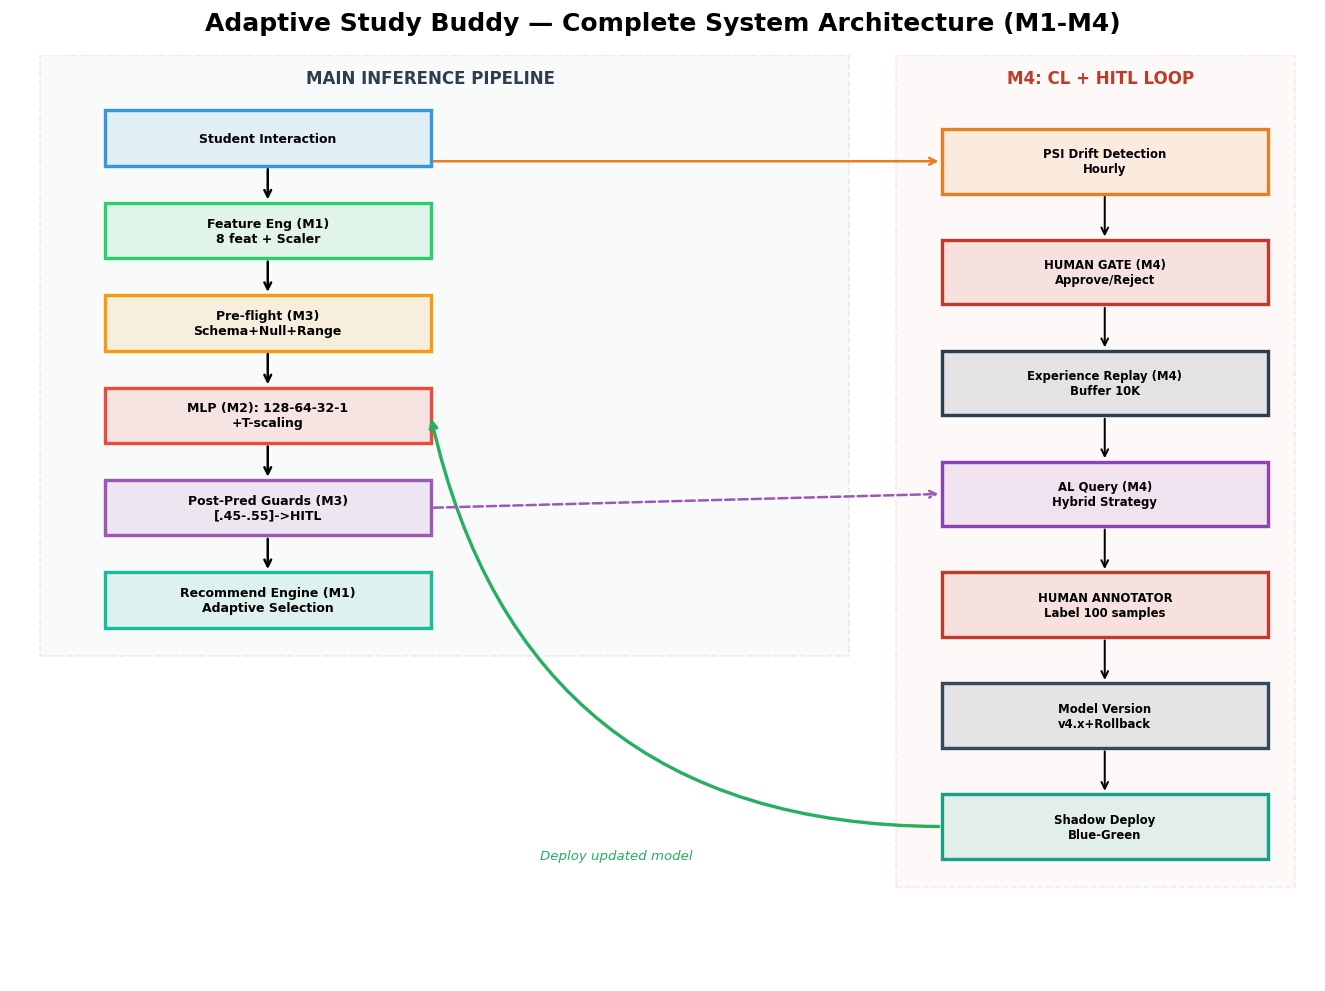

In [ ]:
fig,ax=plt.subplots(1,1,figsize=(14,10)); ax.set_xlim(0,14); ax.set_ylim(0,10); ax.axis('off')
ax.set_title("Adaptive Study Buddy — Complete System Architecture (M1-M4)",fontsize=15,fontweight='bold',pad=15)
ax.add_patch(plt.Rectangle((0.3,3.5),8.7,6.5,lw=1,ec='#bdc3c7',fc='#ecf0f1',alpha=0.3,ls='--'))
ax.text(4.5,9.7,"MAIN INFERENCE PIPELINE",fontsize=10,fontweight='bold',ha='center',color='#2c3e50')
ax.add_patch(plt.Rectangle((9.5,1.0),4.3,9.0,lw=1,ec='#f5b7b1',fc='#fdedec',alpha=0.3,ls='--'))
ax.text(11.7,9.7,"M4: CL + HITL LOOP",fontsize=10,fontweight='bold',ha='center',color='#c0392b')
main=[(1,8.8,3.5,0.6,"Student Interaction","#3498db"),(1,7.8,3.5,0.6,"Feature Eng (M1)\n8 feat + Scaler","#2ecc71"),
    (1,6.8,3.5,0.6,"Pre-flight (M3)\nSchema+Null+Range","#f39c12"),(1,5.8,3.5,0.6,"MLP (M2): 128-64-32-1\n+T-scaling","#e74c3c"),
    (1,4.8,3.5,0.6,"Post-Pred Guards (M3)\n[.45-.55]->HITL","#9b59b6"),(1,3.8,3.5,0.6,"Recommend Engine (M1)\nAdaptive Selection","#1abc9c")]
for x,y,w,h,t,c in main:
    ax.add_patch(plt.Rectangle((x,y),w,h,lw=2,ec=c,fc=c,alpha=0.12))
    ax.add_patch(plt.Rectangle((x,y),w,h,lw=2,ec=c,fc='none'))
    ax.text(x+w/2,y+h/2,t,ha='center',va='center',fontsize=7.5,fontweight='bold')
for i in range(len(main)-1): ax.annotate('',xy=(2.75,main[i+1][1]+main[i+1][3]),xytext=(2.75,main[i][1]),arrowprops=dict(arrowstyle='->',lw=1.5))
m4b=[(10,8.5,3.5,0.7,"PSI Drift Detection\nHourly","#e67e22"),(10,7.3,3.5,0.7,"HUMAN GATE (M4)\nApprove/Reject","#c0392b"),
    (10,6.1,3.5,0.7,"Experience Replay (M4)\nBuffer 10K","#2c3e50"),(10,4.9,3.5,0.7,"AL Query (M4)\nHybrid Strategy","#8e44ad"),
    (10,3.7,3.5,0.7,"HUMAN ANNOTATOR\nLabel 100 samples","#c0392b"),(10,2.5,3.5,0.7,"Model Version\nv4.x+Rollback","#34495e"),
    (10,1.3,3.5,0.7,"Shadow Deploy\nBlue-Green","#16a085")]
for x,y,w,h,t,c in m4b:
    ax.add_patch(plt.Rectangle((x,y),w,h,lw=2,ec=c,fc=c,alpha=0.12))
    ax.add_patch(plt.Rectangle((x,y),w,h,lw=2,ec=c,fc='none'))
    ax.text(x+w/2,y+h/2,t,ha='center',va='center',fontsize=7,fontweight='bold')
for i in range(len(m4b)-1): ax.annotate('',xy=(11.75,m4b[i+1][1]+m4b[i+1][3]),xytext=(11.75,m4b[i][1]),arrowprops=dict(arrowstyle='->',lw=1.2))
ax.annotate('',xy=(10,8.85),xytext=(4.5,8.85),arrowprops=dict(arrowstyle='->',lw=1.5,color='#e67e22'))
ax.annotate('',xy=(4.5,6.1),xytext=(10,1.65),arrowprops=dict(arrowstyle='->',lw=2,color='#27ae60',connectionstyle="arc3,rad=-0.4"))
ax.annotate('',xy=(10,5.25),xytext=(4.5,5.1),arrowprops=dict(arrowstyle='->',lw=1.5,color='#9b59b6',ls='dashed'))
ax.text(6.5,1.3,"Deploy updated model",fontsize=8,color='#27ae60',style='italic',ha='center')
plt.savefig("m4_system_architecture.png",dpi=150,bbox_inches='tight'); plt.show()

### Results Dashboard

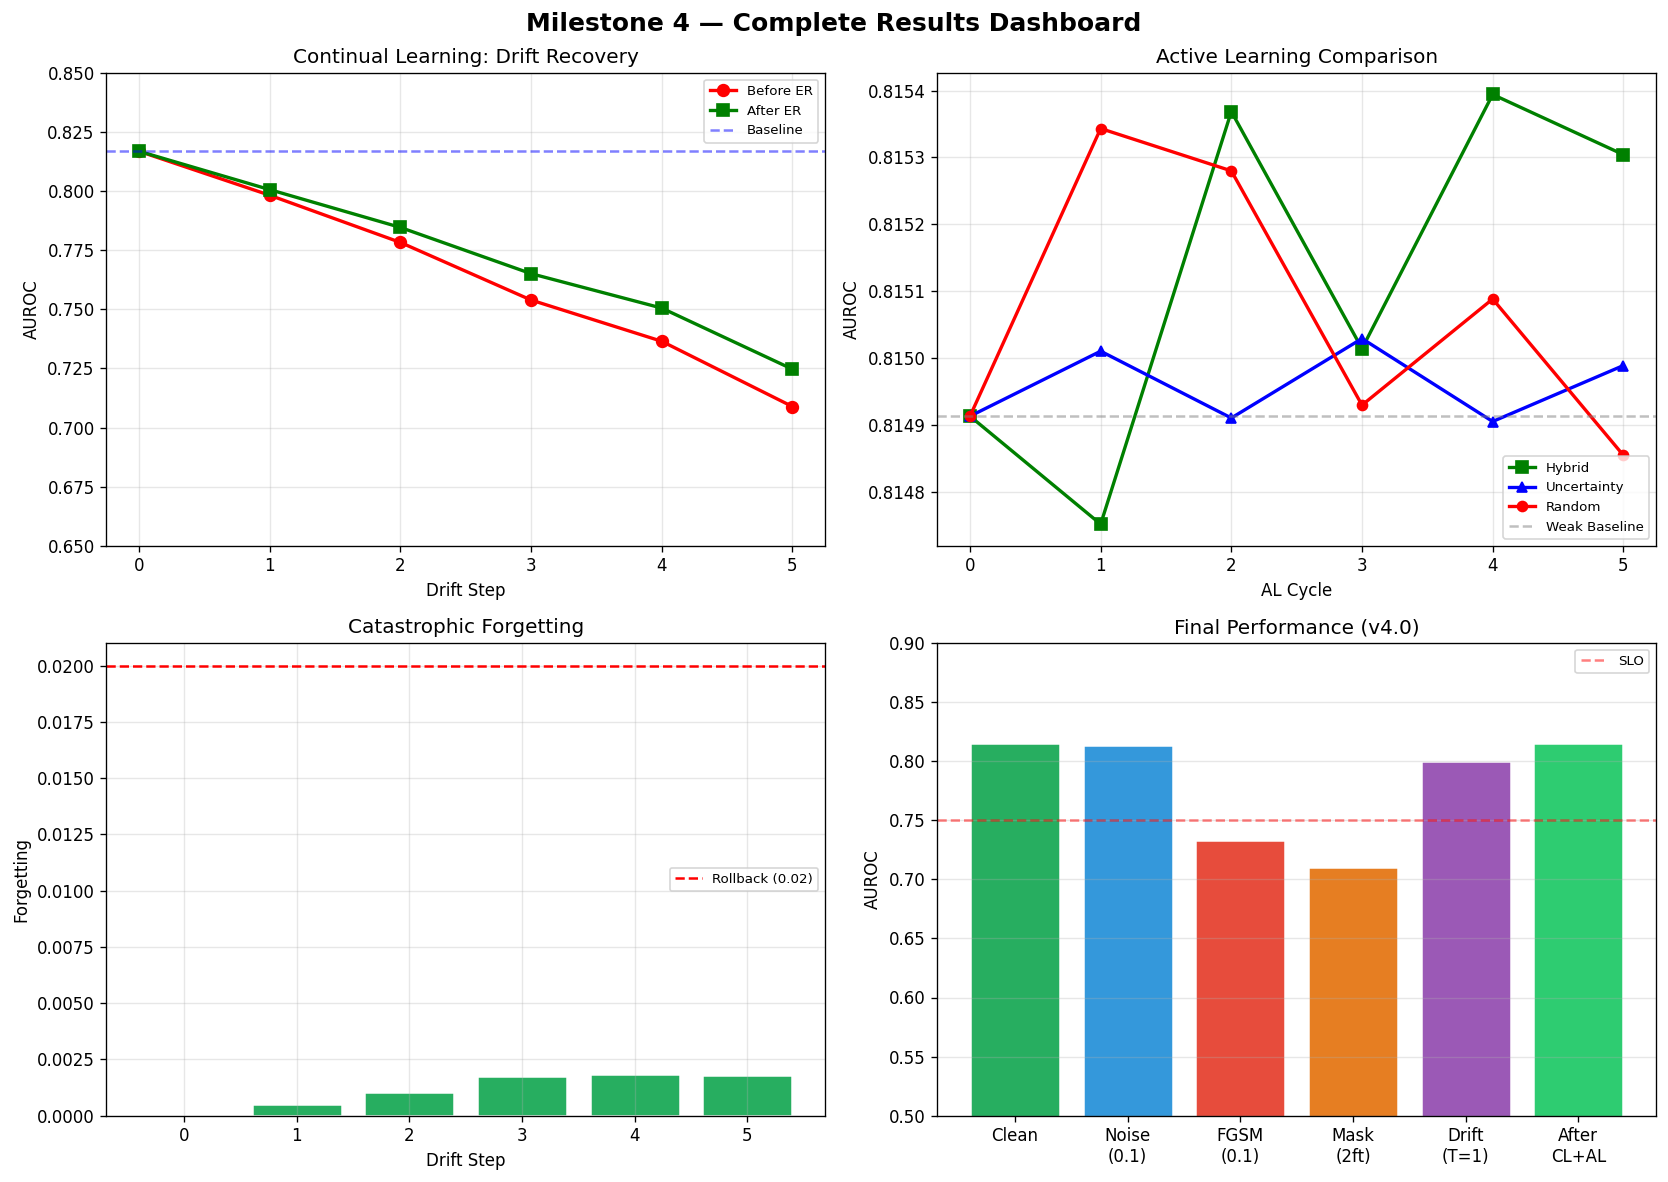

In [ ]:
final_metrics,_=evaluate(model_al,X_test,y_test)
final_latency=measure_latency(model_al,X_test)

X_noisy=X_test+np.random.normal(0,0.1,X_test.shape).astype("float32")
m_noise,_=evaluate(model_al,X_noisy,y_test)

model_al.eval()
Xt=torch.from_numpy(X_test).to(device).requires_grad_(True)
yt=torch.from_numpy(y_test).to(device)
lo=model_al(Xt); la=nn.BCEWithLogitsLoss()(lo,yt); la.backward()
Xf=(Xt+0.1*Xt.grad.sign()).detach().cpu().numpy()
m_fgsm,_=evaluate(model_al,Xf,y_test)

Xm=X_test.copy(); Xm[:,:2]=0
m_mask,_=evaluate(model_al,Xm,y_test)

Xd1,yd1=generate_drifted_data(X_test,y_test,1)
m_d1,_=evaluate(model_al,Xd1,yd1)

fig,axes=plt.subplots(2,2,figsize=(14,10))
fig.suptitle("Milestone 4 — Complete Results Dashboard",fontsize=15,fontweight='bold')

axes[0,0].plot(range(6),auroc_before_list,'r-o',label='Before ER',lw=2,ms=7)
axes[0,0].plot(range(6),auroc_after_list,'g-s',label='After ER',lw=2,ms=7)
axes[0,0].axhline(y=clean_metrics["AUROC"],color='b',ls='--',alpha=0.5,label='Baseline')
axes[0,0].set_xlabel("Drift Step"); axes[0,0].set_ylabel("AUROC")
axes[0,0].set_title("Continual Learning: Drift Recovery"); axes[0,0].legend(fontsize=8)
axes[0,0].grid(True,alpha=0.3); axes[0,0].set_ylim(0.65,0.85)

axes[0,1].plot(range(6),al_results,'g-s',label='Hybrid',lw=2,ms=7)
axes[0,1].plot(range(6),unc_results,'b-^',label='Uncertainty',lw=2,ms=6)
axes[0,1].plot(range(6),rand_results,'r-o',label='Random',lw=2,ms=6)
axes[0,1].axhline(y=weak_metrics["AUROC"],color='gray',ls='--',alpha=0.5,label='Weak Baseline')
axes[0,1].set_xlabel("AL Cycle"); axes[0,1].set_ylabel("AUROC")
axes[0,1].set_title("Active Learning Comparison"); axes[0,1].legend(fontsize=8); axes[0,1].grid(True,alpha=0.3)

colors_fg=['#27ae60' if f<0.005 else '#e67e22' for f in forgetting_list]
axes[1,0].bar(range(6),forgetting_list,color=colors_fg,edgecolor='white',lw=1.5)
axes[1,0].axhline(y=0.02,color='r',ls='--',label='Rollback (0.02)')
axes[1,0].set_xlabel("Drift Step"); axes[1,0].set_ylabel("Forgetting")
axes[1,0].set_title("Catastrophic Forgetting"); axes[1,0].legend(fontsize=8); axes[1,0].grid(True,alpha=0.3)

conds=['Clean','Noise\n(0.1)','FGSM\n(0.1)','Mask\n(2ft)','Drift\n(T=1)','After\nCL+AL']
vals=[final_metrics['AUROC'],m_noise['AUROC'],m_fgsm['AUROC'],m_mask['AUROC'],m_d1['AUROC'],final_metrics['AUROC']]
axes[1,1].bar(conds,vals,color=['#27ae60','#3498db','#e74c3c','#e67e22','#9b59b6','#2ecc71'],edgecolor='white',lw=1.5)
axes[1,1].axhline(y=0.75,color='r',ls='--',alpha=0.5,label='SLO')
axes[1,1].set_ylabel("AUROC"); axes[1,1].set_title("Final Performance (v4.0)")
axes[1,1].legend(fontsize=8); axes[1,1].grid(True,alpha=0.3,axis='y'); axes[1,1].set_ylim(0.5,0.9)

plt.tight_layout()
plt.savefig("m4_results_dashboard.png",dpi=150,bbox_inches='tight'); plt.show()

## Summary & Artifacts

In [ ]:
try:
    import psutil; ram=psutil.Process().memory_info().rss/(1024**2)
except: ram=0

pc=sum(p.numel() for p in model_al.parameters())

print("="*70)
print("CROSS-MILESTONE SUMMARY")
print("="*70)
print(f"{'Metric':<25} {'M3 Baseline':<15} {'M4 Final':<15}")
print("-"*55)
print(f"{'AUROC (clean)':<25} {clean_metrics['AUROC']:<15.4f} {final_metrics['AUROC']:<15.4f}")
print(f"{'F1':<25} {clean_metrics['F1']:<15.4f} {final_metrics['F1']:<15.4f}")
print(f"{'Parameters':<25} {'11,905':<15} {pc:<15,}")
print(f"{'p50 Latency':<25} {baseline_latency['p50_ms']:<15.3f} {final_latency['p50_ms']:<15.3f}")

print(f"\nCL: Before drift T=5: {auroc_before_list[-1]:.4f} -> After ER: {auroc_after_list[-1]:.4f}")
print(f"Max forgetting: {max(forgetting_list):.4f}")
print(f"AL: Weak baseline: {weak_metrics['AUROC']:.4f} -> Hybrid: {al_results[-1]:.4f} (+{gain_h:.4f})")
if gain_r>0: print(f"AL efficiency: {gain_h/gain_r:.1f}x vs random")

dataset_hash=hashlib.sha256(str(len(df)).encode()).hexdigest()[:12]
torch.save({"version":"v4.0","config":CONFIG,"baseline":baseline_state,
    "model_al":model_al.state_dict(),
    "scaler_mean":scaler.mean_.tolist(),"scaler_scale":scaler.scale_.tolist(),
    "features":FEATURES},"milestone4_artifacts.pt")

with open("model_config_v4.txt","w") as f:
    f.write(f"Version: v4.0\nHash: {dataset_hash}\nAUROC: {final_metrics['AUROC']:.4f}\n")
    f.write(f"Config: {json.dumps(CONFIG,indent=2)}\n")

print("\nArtifacts saved. MILESTONE 4 COMPLETE.")

CROSS-MILESTONE SUMMARY
Metric                    M3 Baseline     M4 Final       
-------------------------------------------------------
AUROC (clean)             0.8169          0.8153         
F1                        0.7692          0.7727         
Parameters                11,905          11,905         
p50 Latency               0.207           0.236          

CL: Before drift T=5: 0.7089 -> After ER: 0.7247
Max forgetting: 0.0019
AL: Weak baseline: 0.8149 -> Hybrid: 0.8153 (+0.0004)

Artifacts saved. MILESTONE 4 COMPLETE.
